#### Importamos todas las librerias neecesarias para el proyecto

In [5]:
# Herramientas para manejo de datos y matemáticas
import pandas as pd
import numpy as np

# Herramientas para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de Machine Learning 
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Utilidades adicionales
import io
import base64

#### Verificamos que los datos hayan cargado de forma correcta

In [ ]:
try:
    df = pd.read_csv('heart.csv')
    print(df.info())
    print("\n")
    print(df.head())
except Exception as e:
    print(f"Error: {e}")

#### Cargar el archivo CSV en un DataFrame de Pandas

In [12]:
df = pd.read_csv('heart.csv')

print(f"Dimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas.")
print("\nPrimeras 5 filas de los datos:")
print(df.head())
print("-" * 40)

Dimensiones del dataset: 1025 filas y 14 columnas.

Primeras 5 filas de los datos:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
----------------------------------------


#### Determinar el tipo de problema analizando la columna a predecir ('target').

In [16]:
print("Analizando la columna objetivo ('target')...")
print(f"Valores únicos encontrados en 'target': {df['target'].unique()}")
problem_type = "Clasificación" if len(df['target'].unique()) <= 3 else "Regresión"
print(f"-> Tipo de problema detectado: {problem_type}\n")

Analizando la columna objetivo ('target')...
Valores únicos encontrados en 'target': [0 1]
-> Tipo de problema detectado: Clasificación



#### Deteccion de valores duplicados

In [25]:
duplicates = df.duplicated().sum()
print(f"Filas duplicadas encontradas: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"-> Duplicados eliminados. Nuevo tamaño de los datos: {df.shape[0]} filas.\n")

Filas duplicadas encontradas: 723
-> Duplicados eliminados. Nuevo tamaño de los datos: 302 filas.



#### Deteccion de valores atipicos

In [26]:
continuous_vars = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
outliers_info = {}

for col in continuous_vars:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_info[col] = len(outliers)

# Este otro ciclo for también debe ir en una nueva línea
for col, count in outliers_info.items():
    print(f"- Columna '{col}': {count} valores atípicos.")
print("\n")

- Columna 'age': 0 valores atípicos.
- Columna 'trestbps': 9 valores atípicos.
- Columna 'chol': 5 valores atípicos.
- Columna 'thalach': 1 valores atípicos.
- Columna 'oldpeak': 5 valores atípicos.




#### Preparacion y escalado de los datos

In [27]:
X = df.drop('target', axis=1)
y = df['target']

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Datos divididos exitosamente:")
print(f"- Entrenamiento: {X_train.shape[0]} registros.")
print(f"- Prueba: {X_test.shape[0]} registros.")

# Normalización
print("Escalando las variables continuas (StandardScaler)...")
scaler = StandardScaler()
X_train[continuous_vars] = scaler.fit_transform(X_train[continuous_vars])
X_test[continuous_vars] = scaler.transform(X_test[continuous_vars])
print("-> Datos escalados correctamente.\n")

Datos divididos exitosamente:
- Entrenamiento: 241 registros.
- Prueba: 61 registros.
Escalando las variables continuas (StandardScaler)...
-> Datos escalados correctamente.



## Entrenamiento y optimizaciond el RF

In [28]:
print("Iniciando búsqueda de los mejores hiperparámetros (GridSearchCV)...")
print("Este proceso probará múltiples configuraciones. Por favor espera...")

rf = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# scoring='f1_weighted' para balance multiclase
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print("¡Entrenamiento completado!")
print(f"-> Mejores parámetros elegidos por el modelo:\n{grid_search.best_params_}\n")

Iniciando búsqueda de los mejores hiperparámetros (GridSearchCV)...
Este proceso probará múltiples configuraciones. Por favor espera...
¡Entrenamiento completado!
-> Mejores parámetros elegidos por el modelo:
{'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}



#### Evaluacion con los datos de prueba (Muestra elegida)

In [30]:
y_pred = best_rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
# average='weighted' indispensable para multiclase
f1 = f1_score(y_test, y_pred, average='weighted') 
cm = confusion_matrix(y_test, y_pred)

print(f"Exactitud global (Accuracy): {acc:.4f} ({(acc*100):.1f}%)")
print(f"Puntuación F1 global (Ponderada): {f1:.4f}\n")

print("--- MATRIZ DE CONFUSIÓN ---")
print(cm)
print("\n--- REPORTE DETALLADO POR CLASE ---")
print(classification_report(y_test, y_pred, target_names=['Sano (0)', 'Enfermo (1)']))

Exactitud global (Accuracy): 0.7705 (77.0%)
Puntuación F1 global (Ponderada): 0.7705

--- MATRIZ DE CONFUSIÓN ---
[[21  7]
 [ 7 26]]

--- REPORTE DETALLADO POR CLASE ---
              precision    recall  f1-score   support

    Sano (0)       0.75      0.75      0.75        28
 Enfermo (1)       0.79      0.79      0.79        33

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.77      0.77      0.77        61



#### Generamos graficas para que los resultados sean visibles

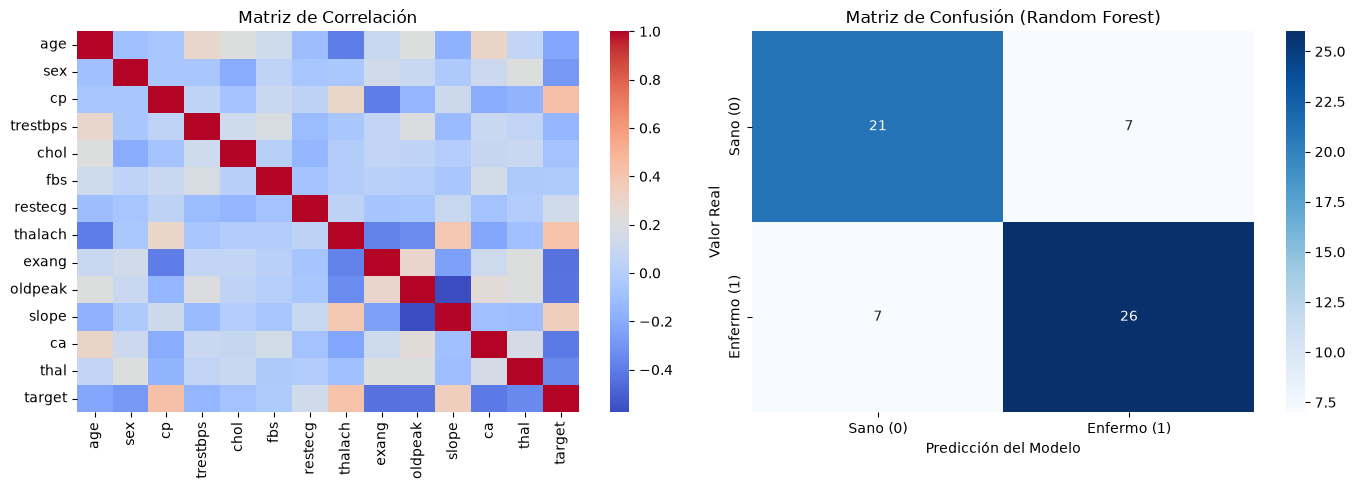

IMAGE_GENERATED: Gráficos guardados y codificados en Base64 exitosamente.


<Figure size 640x480 with 0 Axes>

In [32]:
# Crear la figura con dos subgráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Matriz de Correlación (Usamos 'df', no 'df_clean')
corr = df.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', ax=axes[0])
axes[0].set_title("Matriz de Correlación")

# 2. Matriz de Confusión (Usamos 'cm', no 'cm_c')
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], 
            xticklabels=['Sano (0)', 'Enfermo (1)'], 
            yticklabels=['Sano (0)', 'Enfermo (1)'])
axes[1].set_title("Matriz de Confusión (Random Forest)")
axes[1].set_xlabel("Predicción del Modelo")
axes[1].set_ylabel("Valor Real")

# Ajustar el espacio para que no se superpongan
plt.tight_layout()

# Mostrar el gráfico en pantalla (Muy útil si estás en Jupyter Notebook)
plt.show()

# Guardar la imagen y convertirla a Base64 (Útil para APIs/Web)
plt.savefig("plots.png")
with open("plots.png", "rb") as image_file:
    encoded_string = base64.b64encode(image_file.read()).decode('utf-8')
    
print("IMAGE_GENERATED: Gráficos guardados y codificados en Base64 exitosamente.")